In [1]:
import matplotlib.pyplot as plt 
import agama
import numpy as np 
import hunter2024mwmodel
import barframe
agama.setUnits(length=1,mass=1,velocity=1)

In [2]:
pot = hunter2024mwmodel.mw_model()
omega = -37.5

In [3]:
xL1 = barframe.xL1(pot, omega)
EL1 = barframe.pot_eff(pot, omega, np.array([xL1, 0.0, 0.0]))
E0 = barframe.pot_eff(pot, omega, np.array([0.0, 0.0, 0.0]))

Ej = (49.0 / 50.0) * (EL1 - E0) + E0
xmax = float(barframe.xmaximum_within_bar(pot, omega, Ej))
tolerance = 1e-3

xs = np.linspace(-(1 - tolerance) * xmax, (1 - tolerance) * xmax, 501)
vxs = barframe.vx_zero_velocity_curve(xs, pot, omega, Ej)

xs_poly = np.concatenate((xs, xs[::-1], [xs[0]]))
vxs_poly = np.concatenate((vxs, -vxs[::-1], [vxs[0]]))


In [ ]:
initconds = barframe.sample_initial_conditions_allowed_within_bar(
    pot, omega, Ej, norbits=1,seed=12
)

time_integration = 1e3 * np.sqrt(np.abs(xL1**2 / Ej))

# orbits, lyapunov = agama.orbit(
#     ic=initconds,
#     potential=pot,
#     Omega=omega,
#     time=time_integration,
#     trajsize=int(1e3),
#     lyapunov=True,
#     separateTime=True,
#     dtype=object
# )

In [140]:

def accel_rotating_frame(x, y, vx, vy, pot, omega):
    a = pot.force(np.array([[x, y, 0.0]], dtype=np.float64))[0]
    ax = a[0] + omega**2 * x + 2.0 * omega * vy
    ay = a[1] + omega**2 * y - 2.0 * omega * vx
    return np.array([ax, ay], dtype=np.float64)

def kick_half(state, dt, pot, omega):
    x, y, vx, vy = state
    ax, ay = accel_rotating_frame(x, y, vx, vy, pot, omega)
    vx += 0.5 * dt * ax
    vy += 0.5 * dt * ay
    return np.array([x, y, vx, vy], dtype=np.float64)


def drift(state, dt):
    x, y, vx, vy = state
    x += dt * vx
    y += dt * vy
    return np.array([x, y, vx, vy], dtype=np.float64)


def strang_rotating_frame(state, t_span, dt, pot, omega):
    t0, tf = t_span
    nsteps = int(np.ceil((tf - t0) / dt))
    dt = (tf - t0) / nsteps

    times = t0 + dt * np.arange(nsteps + 1)
    orbit = np.empty((nsteps + 1, 4), dtype=np.float64)
    orbit[0] = state

    for i in range(nsteps):
        tmp = kick_half(orbit[i], dt, pot, omega)
        tmp = drift(tmp, dt)
        tmp = kick_half(tmp, dt, pot, omega)
        orbit[i + 1] = tmp

    return times, orbit

In [141]:
def sos_fill_y_crossings_single_orbit(orbit, omega):
    """
    Extract the (x, vx) section for one orbit using the bar-frame
    Poincaré condition y=0 with upward crossing in the rotating frame.

    orbit is assumed to have shape (nt, 4) with columns:
        [x, y, px, py]
    where px, py are the phase-space momenta in the rotating frame.
    """
    orbit = np.asarray(orbit, dtype=np.float64)
    if orbit.ndim != 2 or orbit.shape[1] != 4:
        raise ValueError("orbit must have shape (nt, 4)")

    nt = orbit.shape[0]
    crossings = []

    for t in range(nt - 1):
        y0 = orbit[t, 1]
        y1 = orbit[t + 1, 1]

        if y0 * y1 >= 0.0:
            continue

        dy = y1 - y0
        if dy == 0.0:
            continue

        alpha = -y0 / dy
        x = (1.0 - alpha) * orbit[t, 0] + alpha * orbit[t + 1, 0]
        y = (1.0 - alpha) * orbit[t, 1] + alpha * orbit[t + 1, 1]
        px = (1.0 - alpha) * orbit[t, 2] + alpha * orbit[t + 1, 2]
        py = (1.0 - alpha) * orbit[t, 3] + alpha * orbit[t + 1, 3]

        ydot = py - omega * x
        if ydot > 0.0:
            vx = px + omega * y
            crossings.append((x, vx))

    if len(crossings) == 0:
        return np.empty((0, 2), dtype=np.float64)

    return np.asarray(crossings, dtype=np.float64)


In [145]:
def jacobi_energy_rotating_frame(state, pot, omega):
    """
    Jacobi constant for the rotating-frame physical variables (x, y, vx, vy).
    This matches the state used in the integrator and the force law.
    """
    x = state[:, 0]
    y = state[:, 1]
    vx = state[:, 2]
    vy = state[:, 3]
    kinetic = 0.5 * (vx**2 + vy**2)
    effective_potential = barframe.pot_eff(
        pot, omega, np.column_stack((x, y, np.zeros_like(x)))
    )
    return kinetic + effective_potential


In [154]:

# test it on one allowed orbit from the bar-frame sample
state0 = np.array(
    [initconds[0, 0], initconds[0, 1], initconds[0, 3] + omega*initconds[0, 1], initconds[0, 4] - omega*initconds[0,0] ],
    dtype=np.float64,
)

time_span = (0.0, 1e3 * np.sqrt(np.abs(xL1**2 / Ej)))
times, orbit = strang_rotating_frame(state0, time_span, 1e-5, pot, omega)

sos = sos_fill_y_crossings_single_orbit(orbit, omega)
print("n crossings:", len(sos))

n crossings: 164


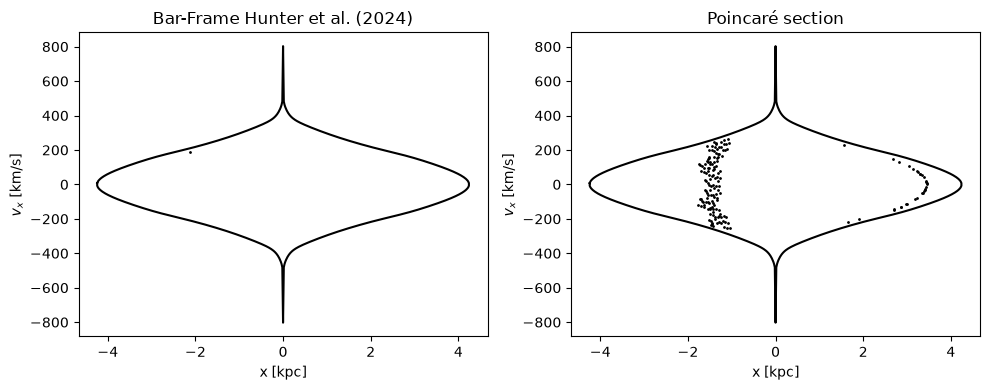

In [155]:
fig, axis = plt.subplots(1, 2, figsize=(10, 4))

axis[0].plot(xs_poly, vxs_poly, color="k")
axis[0].scatter(initconds[:, 0], initconds[:, 3], c="k", s=1)
axis[0].set(
    xlabel="x [kpc]",
    ylabel=r"$v_x$ [km/s]",
    title="Bar-Frame Hunter et al. (2024)"
)

axis[1].plot(xs_poly, vxs_poly, color="k")
axis[1].scatter(sos[:,0], sos[:,1], s=1, color="k")
axis[1].set(
    xlabel="x [kpc]",
    ylabel=r"$v_x$ [km/s]",
    title="Poincaré section"
)

plt.tight_layout()
plt.show()

In [21]:
myorb=orbits[0]

In [47]:
timestamps = np.linspace(0,time_integration,1000)

orbit_index = 0
x = orbits[orbit_index].x(timestamps)
y = orbits[orbit_index].y(timestamps)
vx = orbits[orbit_index].x(timestamps,der=1) - omega*y
vy = orbits[orbit_index].y(timestamps,der=1) + omega*x

# direct Jacobi check
Ej_cross = 0.5*(vx**2 + vy**2) + barframe.pot_eff(
    pot, omega, np.column_stack([x, y, np.zeros_like(x)]))

print("Ej error:", np.max(np.abs((Ej_cross - Ej)/Ej)))

Ej error: 0.0600107840376209


In [48]:
error=np.abs((Ej_cross - Ej)/Ej)

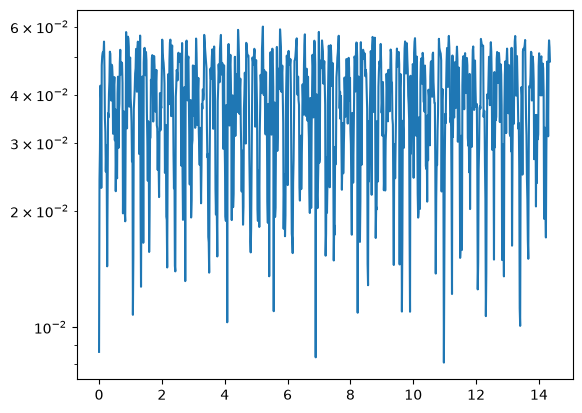

In [49]:
plt.plot(timestamps,error)
plt.yscale("log");